## Iteration_3

**Stage 1 (3s, 5-class):** cargo+passenger+tanker → `large_vessel` | `speed_boat` | `uuv`
- Downsampled majority (large_vessel capped lower) so all 5 original classes train well
- ShipCNN + FocalLoss + WeightedRandomSampler  

**Stage 2 (10s, 3-class):** `cargo_ship` vs `passenger_ship` vs `tanker`
- Raw files re-segmented at 10s with 50% hop (5s stride) — more temporal context
- CNN + GRU architecture to model periodic engine/propeller patterns
- FocalLoss + WeightedRandomSampler — tanker still minority at this stage

**Inference:** Stage 1 predicts; if `large_vessel` → Stage 2 refines to cargo/passenger/tanker


In [ ]:
# =========================
# IMPORTS
# =========================
import os, gc, json, shutil
import numpy as np
import librosa
from pathlib import Path
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# =========================
# STAGE 1 (3s, 5-class)
# =========================
DATA_DIR      = "./data"
DATA_DIR_S2   = "./Datasets"          # cargo/passenger/tanker only
SAVE_DIR      = "./results"
TEMP_DIR      = "./temp_preprocessed"

SR            = 16000

# Stage 1
DURATION_S1   = 3
N_FFT_S1      = 2048
HOP_LENGTH_S1 = 306
N_MELS_S1     = 256
TARGET_FRAMES_S1 = 157      # (16000*3) / 306 = 157
FMAX_S1       = 8000

# Stage 2
DURATION_S2      = 10
N_FFT_S2         = 4096
HOP_LENGTH_S2    = 512
N_MELS_S2        = 256
FMIN_S2          = 20
FMAX_S2          = 1000
TARGET_FRAMES_S2 = int(np.ceil(SR * DURATION_S2 / HOP_LENGTH_S2)) + 1

# Stage 1 balancing
MAJORITY_CAP_S1 = 6_000    # cargo & passenger capped at 6k
MAX_AUG_RATIO   = 3.0
MINORITY_CAP    = 2_000

os.makedirs(TEMP_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"TARGET_FRAMES_S2 = {TARGET_FRAMES_S2}")


TARGET_FRAMES_S2 = 314


In [ ]:
# =========================
# AUDIO UTILITIES
# =========================

def pad_audio(y, target_len):
    if len(y) >= target_len:
        return y[:target_len]
    pad_width = target_len - len(y)
    if pad_width > len(y):
        return np.pad(y, (0, pad_width), mode='edge')
    return np.pad(y, (0, pad_width), mode='reflect')

def preprocess_audio(file_path):
    try:
        y, _ = librosa.load(file_path, sr=SR)
    except Exception:
        return None
    if y is None or len(y) == 0:
        return None
    y, _ = librosa.effects.trim(y)
    if len(y) < SR * 0.5:
        return None
    if np.max(np.abs(y)) == 0:
        return None
    return y

# Stage 1 segmentation
def segment_audio(y, sr=SR, duration=DURATION_S1):
    seg_len = int(sr * duration)
    hop_len = seg_len // 2
    if len(y) >= seg_len:
        return [y[s:s+seg_len] for s in range(0, len(y)-seg_len+1, hop_len)] or [pad_audio(y, seg_len)]
    return [pad_audio(y, seg_len)]

def segment_audio_tight(y, sr=SR, duration=DURATION_S1):
    """25% hop — used for minority augmentation in Stage 1."""
    seg_len = int(sr * duration)
    hop_len = seg_len // 4
    segs = [y[s:s+seg_len] for s in range(0, len(y)-seg_len+1, hop_len)]
    return segs if segs else [pad_audio(y, seg_len)]

# Stage 2 segmentation
def segment_audio_s2(y, sr=SR, duration=DURATION_S2):
    """10s windows with 5s hop (50% overlap) for Stage 2.
    Periodic engine signals — overlapping windows add genuine diversity.
    """
    seg_len = int(sr * duration)
    hop_len = seg_len // 2
    if len(y) >= seg_len:
        segs = [y[s:s+seg_len] for s in range(0, len(y)-seg_len+1, hop_len)]
        return segs if segs else [pad_audio(y, seg_len)]
    return [pad_audio(y, seg_len)]             # pad short clips

# Spec augment
def spec_augment(spec, freq_mask=10, time_mask=10):
    spec       = spec.copy()
    mask_value = -80.0
    f  = np.random.randint(1, freq_mask + 1)
    f0 = np.random.randint(0, spec.shape[0] - f)
    spec[f0:f0+f, :] = mask_value
    t  = np.random.randint(1, time_mask + 1)
    t0 = np.random.randint(0, spec.shape[1] - t)
    spec[:, t0:t0+t] = mask_value
    return spec

# Stage 1 feature extraction
def extract_logmel_s1(y, apply_specaug=False):
    mel     = librosa.feature.melspectrogram(
        y=y, sr=SR, n_mels=N_MELS_S1, n_fft=N_FFT_S1,
        hop_length=HOP_LENGTH_S1, fmax=FMAX_S1
    )
    log_mel = librosa.power_to_db(mel, ref=1.0)
    log_mel = np.clip(log_mel, -80, 0)
    if log_mel.shape[1] < TARGET_FRAMES_S1:
        log_mel = np.pad(log_mel, ((0,0),(0, TARGET_FRAMES_S1-log_mel.shape[1])))
    else:
        log_mel = log_mel[:, :TARGET_FRAMES_S1]
    if apply_specaug:
        log_mel = spec_augment(log_mel)
    return log_mel[np.newaxis, :, :]   # (1, N_MELS_S1, TARGET_FRAMES_S1)

# Stage 2 feature extraction
def extract_logmel_s2(y, apply_specaug=False):
    """Low-frequency focused, 3-channel for Stage 2.
    fmin=20, fmax=1000 concentrates mel bins where blade rate harmonics live.
    """
    mel     = librosa.feature.melspectrogram(
        y=y, sr=SR, n_mels=N_MELS_S2, n_fft=N_FFT_S2,
        hop_length=HOP_LENGTH_S2, fmin=FMIN_S2, fmax=FMAX_S2
    )
    log_mel = librosa.power_to_db(mel, ref=1.0)
    log_mel = np.clip(log_mel, -80, 0)
    delta   = librosa.feature.delta(log_mel)
    delta2  = librosa.feature.delta(log_mel, order=2)

    def fix_len(arr):
        if arr.shape[1] < TARGET_FRAMES_S2:
            return np.pad(arr, ((0,0),(0, TARGET_FRAMES_S2-arr.shape[1])))
        return arr[:, :TARGET_FRAMES_S2]

    log_mel, delta, delta2 = fix_len(log_mel), fix_len(delta), fix_len(delta2)
    if apply_specaug:
        log_mel = spec_augment(log_mel, freq_mask=15, time_mask=20)

    return np.stack([log_mel, delta, delta2], axis=0)  # (3, N_MELS_S2, TARGET_FRAMES_S2)

extract_logmel = extract_logmel_s1


In [ ]:
# =========================
# AUGMENTATION
# =========================

def add_noise(y, snr_db):
    sig_pwr = np.mean(y**2) + 1e-8
    noise   = np.random.normal(0, np.sqrt(sig_pwr / 10**(snr_db/10)), len(y))
    return y + noise

def gain_scale(y):
    return y * np.random.uniform(0.7, 1.3)

def time_stretch(y):
    rate = np.random.uniform(0.9, 1.1)
    return pad_audio(librosa.effects.time_stretch(y, rate=rate), len(y))

def pitch_shift_safe(y):
    return librosa.effects.pitch_shift(y, sr=SR, n_steps=np.random.uniform(-1.0, 1.0))

# Stage 1 minority pool
_AUG_MINORITY = [
    lambda y: add_noise(y, snr_db=np.random.uniform(5, 20)),
    lambda y: gain_scale(y),
    lambda y: time_stretch(y),
    lambda y: pitch_shift_safe(y),
    lambda y: add_noise(gain_scale(y), snr_db=np.random.uniform(5, 20)),
    lambda y: add_noise(time_stretch(y), snr_db=np.random.uniform(5, 20)),
]

# Stage 1 majority pool
_AUG_MAJORITY = [
    lambda y: add_noise(y, snr_db=np.random.uniform(5, 20)),
    lambda y: gain_scale(y),
    lambda y: time_stretch(y),
]

# Stage 2 pool
_AUG_S2 = [
    lambda y: add_noise(y, snr_db=np.random.uniform(8, 25)),
    lambda y: gain_scale(y),
    lambda y: add_noise(gain_scale(y), snr_db=np.random.uniform(8, 25)),
]

def augment_one(y, minority=False, stage2=False):
    if stage2:
        pool = _AUG_S2
    elif minority:
        pool = _AUG_MINORITY
    else:
        pool = _AUG_MAJORITY
    return pool[np.random.randint(len(pool))](y)


In [ ]:
# =========================
# MODELS & DATASET
# =========================

class ShipDataset(Dataset):
    def __init__(self, mmap_path, labels, shape, shuffle_idx=None):
        self.labels      = labels
        self.shuffle_idx = shuffle_idx
        self.data        = np.memmap(mmap_path, dtype='float32', mode='r', shape=shape)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        real_idx = self.shuffle_idx[idx] if self.shuffle_idx is not None else idx
        sample   = np.array(self.data[real_idx], copy=True)
        return torch.from_numpy(sample).float(), torch.tensor(self.labels[idx], dtype=torch.long)


# SE block
class SE(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels//reduction), nn.ReLU(),
            nn.Linear(channels//reduction, channels), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.fc(x).view(-1, x.shape[1], 1, 1)


# Attention Pool
class AttentionPool(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.attn = nn.Conv2d(channels, 1, 1)
    def forward(self, x):
        w   = torch.softmax(self.attn(x).flatten(2), dim=-1)
        out = (x.flatten(2) * w).sum(-1)
        return out   # (B, C)


# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        return ((1 - torch.exp(-ce))**self.gamma * ce).mean()


# ══════════════════════════════════════════════════════════════
# STAGE 1 MODEL — ShipCNN (1-channel, 5-class)
# ══════════════════════════════════════════════════════════════
class ShipCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.3),
        )
        self.se3   = SE(128)
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.se4       = SE(256)
        self.pool      = AttentionPool(256)
        self.classifier = nn.Sequential(
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.se3(self.block3(x))
        x = self.se4(self.block4(x))
        x = self.pool(x)
        return self.classifier(x)


# ══════════════════════════════════════════════════════════════
# STAGE 2 MODEL — CNN + GRU (3-channel, 3-class)
# Designed for 10s low-frequency spectrograms.
# CNN extracts per-frame features; GRU models temporal periodicity.
# ══════════════════════════════════════════════════════════════
class LargeVesselCNNGRU(nn.Module):
    """
    Input: (B, 3, N_MELS_S2, TARGET_FRAMES_S2)
    CNN encodes frequency content per time-step.
    GRU models blade-rate periodicity across the 10s window.
    """
    def __init__(self, num_classes=3, n_mels=256, gru_hidden=128):
        super().__init__()

        # CNN — processes (B, 3, n_mels, T) → (B, 256, n_mels//16, T//4)
        self.cnn = nn.Sequential(
            # block 1 — 3→32
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d((2,1)),  nn.Dropout(0.2),   # pool freq only
            # block 2 — 32→64
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d((2,1)),  nn.Dropout(0.2),
            # block 3 — 64→128 + SE
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2,1)),  nn.Dropout(0.3),
            # block 4 — 128→256 + SE
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2,1)),                        # (B, 256, n_mels//16, T)
        )
        self.se_cnn = SE(256)

        freq_dim = n_mels // 16
        self.freq_proj = nn.Linear(256 * freq_dim, 256)

        # GRU — models temporal patterns over the 10s window
        self.gru = nn.GRU(
            input_size=256, hidden_size=gru_hidden,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.3,
        )

        self.classifier = nn.Sequential(
            nn.Linear(gru_hidden * 2, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, return_embedding=False):
        x = self.cnn(x)
        x = self.se_cnn(x)
        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(B, T, C * F)
        x = self.freq_proj(x)
        _, h = self.gru(x)
        h = torch.cat([h[-2], h[-1]], dim=1)
        logits = self.classifier(h)
        if return_embedding:
            return logits, h
        return logits


---
## STAGE 1 — Data Pipeline (3s, 5-class)
Run cells 8→17 once, then skip to RESTORE on subsequent sessions.


In [ ]:
# =========================
# STEP 1 — DATA COLLECTION
# =========================
wav_files = list(Path(DATA_DIR).rglob("*.wav"))
print(f"Found {len(wav_files)} files.")

# Pass 1: count segments without loading spectrograms
print("Pass 1/2: counting segments...")
seg_counts, valid_files = [], []
for file_path in wav_files:
    signal = preprocess_audio(str(file_path))
    if signal is None:
        continue
    seg_counts.append(len(segment_audio(signal)))
    valid_files.append(file_path)

total_segments = sum(seg_counts)
print(f"Total segments: {total_segments}")

# Build label mapping
unique_label_names = sorted(set(p.parent.name for p in valid_files))
label_to_idx = {name: i for i, name in enumerate(unique_label_names)}
idx_to_label = {i: name for name, i in label_to_idx.items()}
print("Label mapping:", label_to_idx)

# Pre-allocate memmap on SSD
mmap_orig_path = os.path.join(TEMP_DIR, "X_orig_mmap.dat")
X_orig_mmap    = np.memmap(mmap_orig_path, dtype='float32', mode='w+',
                           shape=(total_segments, 1, N_MELS_S1, TARGET_FRAMES_S1))
y_orig         = np.empty(total_segments, dtype=np.int32)
file_ids_orig  = np.empty(total_segments, dtype=object)

# Pass 2: extract spectrograms
print("Pass 2/2: extracting spectrograms...")
write_idx = 0
for file_path, n_segs in tqdm(zip(valid_files, seg_counts), total=len(valid_files)):
    signal = preprocess_audio(str(file_path))
    if signal is None:
        continue
    label_idx = label_to_idx[file_path.parent.name]
    for seg in segment_audio(signal):
        X_orig_mmap[write_idx] = extract_logmel(seg, apply_specaug=False)
        y_orig[write_idx]      = label_idx
        file_ids_orig[write_idx] = str(file_path)
        write_idx += 1

X_orig_mmap.flush()

if write_idx < total_segments:
    print(f"  Trimmed {total_segments - write_idx} pre-allocated rows")
    X_orig_mmap    = X_orig_mmap[:write_idx]
    y_orig         = y_orig[:write_idx]
    file_ids_orig  = file_ids_orig[:write_idx]
    total_segments = write_idx

print(f"\nOriginal dataset: {X_orig_mmap.shape}")
print("Class counts:", {idx_to_label[k]: v for k, v in Counter(y_orig).items()})

# Save metadata
np.save(os.path.join(TEMP_DIR, "y_orig.npy"), y_orig)
np.save(os.path.join(TEMP_DIR, "file_ids_orig.npy"), file_ids_orig)
meta = {
    "label_to_idx": label_to_idx,   # plain dict — JSON-safe
    "idx_to_label": {str(k): v for k, v in idx_to_label.items()},
    "total_segments": int(total_segments),
    "shape": list(X_orig_mmap.shape),
    "dtype": "float32",
}
with open(os.path.join(TEMP_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
X_orig_mmap.flush()

# Copy to Drive
for fname in ["X_orig_mmap.dat", "y_orig.npy", "file_ids_orig.npy", "meta.json"]:
    src = os.path.join(TEMP_DIR, fname)
    dst = os.path.join(SAVE_DIR, fname)
    if os.path.exists(src):
        if os.path.exists(dst): os.remove(dst)
        shutil.copy(src, dst)
        print(f"  Copied to Drive: {fname} ({os.path.getsize(dst)/1e6:.1f} MB)")
print("Step 1 complete.")

Found 1691 files.
Pass 1/2: counting segments...
Total segments: 55924
Label mapping: {'cargo_ship': 0, 'passenger_ship': 1, 'speed_boat': 2, 'tanker': 3, 'uuv': 4}
Pass 2/2: extracting spectrograms...


100%|██████████| 1691/1691 [14:46<00:00,  1.91it/s]



Original dataset: (55924, 1, 256, 157)
Class counts: {'tanker': 1021, 'uuv': 902, 'passenger_ship': 28010, 'cargo_ship': 25521, 'speed_boat': 470}
  Copied to Drive: X_orig_mmap.dat (8990.8 MB)
  Copied to Drive: y_orig.npy (0.2 MB)
  Copied to Drive: file_ids_orig.npy (0.5 MB)
  Copied to Drive: meta.json (0.0 MB)
Step 1 complete.


In [ ]:
# =========================
# STEP 1 — RESTORE  
# =========================
src = os.path.join(SAVE_DIR, "X_orig_mmap.dat")
dst = os.path.join(TEMP_DIR, "X_orig_mmap.dat")
if not os.path.exists(dst):
    print("Copying X_orig_mmap.dat from Drive (this may take a while)...")
    shutil.copy(src, dst)
    print("Done.")
else:
    print("X_orig_mmap.dat already in TEMP_DIR, skipping copy.")

for fname in ["meta.json", "y_orig.npy", "file_ids_orig.npy"]:
    shutil.copy(os.path.join(SAVE_DIR, fname), os.path.join(TEMP_DIR, fname))
    print(f"Restored: {fname}")

with open(os.path.join(TEMP_DIR, "meta.json")) as f:
    meta_info = json.load(f)

total_segments = meta_info["total_segments"]
label_to_idx   = meta_info["label_to_idx"]
idx_to_label   = {int(k): v for k, v in meta_info["idx_to_label"].items()}

y_orig        = np.load(os.path.join(TEMP_DIR, "y_orig.npy"))
file_ids_orig = np.load(os.path.join(TEMP_DIR, "file_ids_orig.npy"), allow_pickle=True)
X_orig_mmap   = np.memmap(os.path.join(TEMP_DIR, "X_orig_mmap.dat"),
                          dtype='float32', mode='r+',
                          shape=(total_segments, 1, N_MELS_S1, TARGET_FRAMES_S1))

print(f"\nStep 1 restored. total_segments={total_segments}")
print("label_to_idx:", label_to_idx)
print("Class counts:", {idx_to_label[k]: v for k, v in Counter(y_orig.tolist()).items()})
print("Ready for Step 2 (splitting).")


X_orig_mmap.dat already in TEMP_DIR, skipping copy.
Restored: meta.json
Restored: y_orig.npy
Restored: file_ids_orig.npy

Step 1 restored. total_segments=55924
label_to_idx: {'cargo_ship': 0, 'passenger_ship': 1, 'speed_boat': 2, 'tanker': 3, 'uuv': 4}
Class counts: {'tanker': 1021, 'uuv': 902, 'passenger_ship': 28010, 'cargo_ship': 25521, 'speed_boat': 470}
Ready for Step 2 (splitting).


---
## STEP 2 — Stratified Split (file-level)

In [ ]:
# =========================
# STEP 2 — SPLITTING
# =========================
unique_files  = np.unique(file_ids_orig)
unique_labels = np.array([y_orig[file_ids_orig == f][0] for f in unique_files])

label_counts = Counter(unique_labels)
print("File-level class counts:", {idx_to_label[k]: v for k, v in label_counts.items()})

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(sss1.split(unique_files, unique_labels))
train_files = unique_files[train_idx]
temp_files  = unique_files[temp_idx]
temp_labels = unique_labels[temp_idx]

temp_label_counts  = Counter(temp_labels)
can_stratify_split = all(c >= 2 for c in temp_label_counts.values())

if can_stratify_split:
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    val_idx, test_idx = next(sss2.split(temp_files, temp_labels))
else:
    from sklearn.model_selection import ShuffleSplit
    print("WARNING: falling back to random val/test split (rare classes < 2 files in temp)")
    val_idx, test_idx = next(ShuffleSplit(n_splits=1, test_size=0.5, random_state=42).split(temp_files))

val_files  = temp_files[val_idx]
test_files = temp_files[test_idx]

train_mask = np.isin(file_ids_orig, train_files)
val_mask   = np.isin(file_ids_orig, val_files)
test_mask  = np.isin(file_ids_orig, test_files)

train_indices  = np.where(train_mask)[0]
y_train_orig   = y_orig[train_mask]
train_file_ids = file_ids_orig[train_mask]
y_val          = y_orig[val_mask]
y_test         = y_orig[test_mask]

# Warn if any split is missing a class
num_classes = len(label_to_idx)
for split_name, y_split in [("Val", y_val), ("Test", y_test)]:
    missing = set(range(num_classes)) - set(np.unique(y_split))
    if missing:
        print(f"WARNING: {split_name} missing classes: {[idx_to_label[i] for i in missing]}"
              " — consider adjusting test_size or random_state")

print(f"\nTrain segs: {train_mask.sum()} | Val segs: {val_mask.sum()} | Test segs: {test_mask.sum()}")
for split_name, y_split in [("Train", y_train_orig), ("Val", y_val), ("Test", y_test)]:
    counts = Counter(y_split)
    total  = len(y_split)
    dist   = {idx_to_label[k]: f"{v} ({100*v/total:.1f}%)" for k, v in sorted(counts.items())}
    print(f"  {split_name:5s}: {dist}")

# Save file-level split
np.save(os.path.join(TEMP_DIR, "train_files.npy"),   train_files)
np.save(os.path.join(TEMP_DIR, "val_files.npy"),     val_files)
np.save(os.path.join(TEMP_DIR, "test_files.npy"),    test_files)
np.save(os.path.join(TEMP_DIR, "train_indices.npy"), train_indices)
np.save(os.path.join(TEMP_DIR, "y_train_orig.npy"),  y_train_orig)
np.savez(os.path.join(TEMP_DIR, "split_indices.npz"),
         train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

X_val = np.array(X_orig_mmap[val_mask], dtype=np.float32)
np.savez(os.path.join(TEMP_DIR, "val_raw.npz"), X=X_val, y=y_val)
del X_val; gc.collect()

X_test = np.array(X_orig_mmap[test_mask], dtype=np.float32)
np.savez(os.path.join(TEMP_DIR, "test_raw.npz"), X=X_test, y=y_test)
del X_test; gc.collect()

# Copy to Drive
for fname in ["train_files.npy", "val_files.npy", "test_files.npy",
              "train_indices.npy", "y_train_orig.npy",
              "split_indices.npz", "val_raw.npz", "test_raw.npz"]:
    src = os.path.join(TEMP_DIR, fname)
    dst = os.path.join(SAVE_DIR, fname)
    if os.path.exists(src):
        if os.path.exists(dst): os.remove(dst)
        shutil.copy(src, dst)
        print(f"  Copied to Drive: {fname}")

print("Step 2 complete.")


File-level class counts: {'cargo_ship': 109, 'passenger_ship': 184, 'speed_boat': 470, 'tanker': 26, 'uuv': 902}

Train segs: 40514 | Val segs: 8289 | Test segs: 7121
  Train: {'cargo_ship': '18932 (46.7%)', 'passenger_ship': '19997 (49.4%)', 'speed_boat': '329 (0.8%)', 'tanker': '625 (1.5%)', 'uuv': '631 (1.6%)'}
  Val  : {'cargo_ship': '2992 (36.1%)', 'passenger_ship': '4850 (58.5%)', 'speed_boat': '70 (0.8%)', 'tanker': '241 (2.9%)', 'uuv': '136 (1.6%)'}
  Test : {'cargo_ship': '3597 (50.5%)', 'passenger_ship': '3163 (44.4%)', 'speed_boat': '71 (1.0%)', 'tanker': '155 (2.2%)', 'uuv': '135 (1.9%)'}
  Copied to Drive: train_files.npy
  Copied to Drive: val_files.npy
  Copied to Drive: test_files.npy
  Copied to Drive: train_indices.npy
  Copied to Drive: y_train_orig.npy
  Copied to Drive: split_indices.npz
  Copied to Drive: val_raw.npz
  Copied to Drive: test_raw.npz
Step 2 complete.


---
## STEP 2 — RESTORE
Run **Step 1 RESTORE** first, then this cell to skip re-splitting on subsequent sessions.


In [ ]:
# =========================
# STEP 2 — RESTORE
# Requires: X_orig_mmap, file_ids_orig, idx_to_label in memory (from Step 1 RESTORE).
# =========================
for fname in ["train_files.npy", "val_files.npy", "test_files.npy",
              "train_indices.npy", "y_train_orig.npy",
              "split_indices.npz", "val_raw.npz", "test_raw.npz"]:
    shutil.copy(os.path.join(SAVE_DIR, fname), os.path.join(TEMP_DIR, fname))
    print(f"Restored: {fname}")

train_files   = np.load(os.path.join(TEMP_DIR, "train_files.npy"),   allow_pickle=True)
val_files     = np.load(os.path.join(TEMP_DIR, "val_files.npy"),     allow_pickle=True)
test_files    = np.load(os.path.join(TEMP_DIR, "test_files.npy"),    allow_pickle=True)
train_indices = np.load(os.path.join(TEMP_DIR, "train_indices.npy"))
y_train_orig  = np.load(os.path.join(TEMP_DIR, "y_train_orig.npy"))

split          = np.load(os.path.join(TEMP_DIR, "split_indices.npz"))
train_mask     = split["train_mask"]
val_mask       = split["val_mask"]
test_mask      = split["test_mask"]
train_file_ids = file_ids_orig[train_mask]

val_data  = np.load(os.path.join(TEMP_DIR, "val_raw.npz"))
test_data = np.load(os.path.join(TEMP_DIR, "test_raw.npz"))
y_val  = val_data["y"]
y_test = test_data["y"]

print(f"\nStep 2 restored.")
print(f"Train files: {len(train_files)} | Val files: {len(val_files)} | Test files: {len(test_files)}")
print(f"Train segs: {train_mask.sum()} | Val segs: {len(y_val)} | Test segs: {len(y_test)}")
for split_name, y_split in [("Train", y_train_orig), ("Val", y_val), ("Test", y_test)]:
    counts = Counter(y_split.tolist())
    total  = len(y_split)
    dist   = {idx_to_label[k]: f"{v} ({100*v/total:.1f}%)" for k, v in sorted(counts.items())}
    print(f"  {split_name:5s}: {dist}")
print("Ready for Step 3.")


Restored: train_files.npy
Restored: val_files.npy
Restored: test_files.npy
Restored: train_indices.npy
Restored: y_train_orig.npy
Restored: split_indices.npz
Restored: val_raw.npz
Restored: test_raw.npz

Step 2 restored.
Train files: 1183 | Val files: 254 | Test files: 254
Train segs: 40514 | Val segs: 8289 | Test segs: 7121
  Train: {'cargo_ship': '18932 (46.7%)', 'passenger_ship': '19997 (49.4%)', 'speed_boat': '329 (0.8%)', 'tanker': '625 (1.5%)', 'uuv': '631 (1.6%)'}
  Val  : {'cargo_ship': '2992 (36.1%)', 'passenger_ship': '4850 (58.5%)', 'speed_boat': '70 (0.8%)', 'tanker': '241 (2.9%)', 'uuv': '136 (1.6%)'}
  Test : {'cargo_ship': '3597 (50.5%)', 'passenger_ship': '3163 (44.4%)', 'speed_boat': '71 (1.0%)', 'tanker': '155 (2.2%)', 'uuv': '135 (1.9%)'}
Ready for Step 3.


---
## STEP 3 — Balancing + Augmentation

In [ ]:
# =========================
# STEP 3 — BALANCING + AUGMENTATION
# Keep all majority data up to MAJORITY_CAP_S1.
# Augment minorities up to 3x real, capped at MINORITY_CAP.
# =========================
X_train_bal_path = os.path.join(TEMP_DIR, "X_train_balanced.dat")
y_train_bal_path = os.path.join(TEMP_DIR, "y_train_balanced.npy")

MAJORITY_CAP  = MAJORITY_CAP_S1
MAX_AUG_RATIO = 3.0
MINORITY_CAP  = 2_000

class_counts = Counter(y_train_orig)
label_list   = sorted(class_counts.keys())

targets = {}
for label, count in class_counts.items():
    if count >= 1000:
        targets[label] = min(count, MAJORITY_CAP)
    else:
        targets[label] = min(int(count * MAX_AUG_RATIO), MINORITY_CAP)

n_total = sum(targets.values())
print("Targets per class:")
for label, target in targets.items():
    real = class_counts[label]
    aug  = max(0, target - real)
    print(f"  {idx_to_label[label]:20s}: {real:6d} real + {aug:5d} aug = {target:6d}")
print(f"  Total: {n_total}  |  Memmap: {n_total * 1 * N_MELS_S1 * TARGET_FRAMES_S1 * 4 / 1e9:.2f} GB")

X_mmap = np.memmap(X_train_bal_path, dtype='float32', mode='w+',
                   shape=(n_total, 1, N_MELS_S1, TARGET_FRAMES_S1))
y_bal  = np.empty(n_total, dtype=np.int32)

RNG         = np.random.default_rng(42)
shuffle_idx = RNG.permutation(n_total).astype(np.int64)

write_idx   = 0
audio_cache = {}
seg_cache   = {}

for label in label_list:
    class_name  = idx_to_label[label]
    cls_indices = np.where(y_train_orig == label)[0]
    n_real      = len(cls_indices)
    target      = targets[label]
    print(f"\nProcessing {class_name} ({n_real} real → {target} target)...")

    if n_real >= 1000:
        # Majority — randomly subsample to cap, no augmentation
        selected = RNG.choice(cls_indices, target, replace=False)
        for idx in selected:
            orig_idx = train_indices[idx]
            X_mmap[write_idx] = X_orig_mmap[orig_idx]
            y_bal[write_idx]  = label
            write_idx        += 1

    else:
        # Minority — write all real samples first
        for idx in cls_indices:
            orig_idx = train_indices[idx]
            X_mmap[write_idx] = X_orig_mmap[orig_idx]
            y_bal[write_idx]  = label
            write_idx        += 1

        # Augment up to target
        n_needed       = target - n_real
        generated      = 0
        label_file_ids = np.unique(train_file_ids[y_train_orig == label])

        while generated < n_needed:
            fpath = np.random.choice(label_file_ids)
            if fpath not in audio_cache:
                signal = preprocess_audio(fpath)
                if signal is None:
                    continue
                audio_cache[fpath] = signal
                seg_cache[fpath]   = segment_audio_tight(signal)
            for seg in seg_cache[fpath]:
                if generated >= n_needed:
                    break
                spec              = extract_logmel(augment_one(seg, minority=True), apply_specaug=True)
                X_mmap[write_idx] = spec
                y_bal[write_idx]  = label
                write_idx        += 1
                generated        += 1

        audio_cache.clear()
        seg_cache.clear()

X_mmap.flush()

np.save(y_train_bal_path, y_bal)
np.save(os.path.join(TEMP_DIR, "shuffle_idx.npy"), shuffle_idx)

print(f"\nBalancing complete. Total: {n_total} samples.")
print("Final counts:", {idx_to_label[k]: v for k, v in Counter(y_bal.tolist()).items()})


Targets per class:
  tanker              :    625 real +  1250 aug =   1875
  uuv                 :    631 real +  1262 aug =   1893
  passenger_ship      :  19997 real +     0 aug =   6000
  cargo_ship          :  18932 real +     0 aug =   6000
  speed_boat          :    329 real +   658 aug =    987
  Total: 16755  |  Memmap: 2.69 GB

Processing cargo_ship (18932 real → 6000 target)...

Processing passenger_ship (19997 real → 6000 target)...

Processing speed_boat (329 real → 987 target)...

Processing tanker (625 real → 1875 target)...

Processing uuv (631 real → 1893 target)...

Balancing complete. Total: 16755 samples.
Final counts: {'cargo_ship': 6000, 'passenger_ship': 6000, 'speed_boat': 987, 'tanker': 1875, 'uuv': 1893}


---
## STEP 4 — GPU Normalization

In [ ]:
# =========================
# STEP 4 — GPU NORMALIZATION
# =========================
LOCAL_PATH = os.path.join(TEMP_DIR, "X_train_norm.dat")
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_mmap = np.memmap(X_train_bal_path, dtype='float32', mode='r',
                   shape=(n_total, 1, N_MELS_S1, TARGET_FRAMES_S1))

CHUNK = 1000  # conservative for 12.5 GB RAM

# Pass 1: compute mean and std
sum_val, sum_sq_val, n_pixels = 0.0, 0.0, 0
for i in tqdm(range(0, n_total, CHUNK), desc="Computing stats"):
    chunk       = torch.from_numpy(X_mmap[i:i+CHUNK].astype(np.float32)).to(device)
    sum_val    += chunk.sum().item()
    sum_sq_val += chunk.pow(2).sum().item()
    n_pixels   += chunk.numel()
    del chunk

train_mean = sum_val / n_pixels
train_std  = float(np.sqrt((sum_sq_val / n_pixels) - (train_mean ** 2))) + 1e-8
print(f"Train mean: {train_mean:.6f}  |  Train std: {train_std:.6f}")

# Pass 2: write normalized data to a new memmap
X_train_norm = np.memmap(LOCAL_PATH, dtype='float32', mode='w+', shape=X_mmap.shape)
for i in tqdm(range(0, n_total, CHUNK), desc="Normalizing"):
    chunk = torch.from_numpy(X_mmap[i:i+CHUNK].astype(np.float32)).to(device)
    X_train_norm[i:i+CHUNK] = ((chunk - train_mean) / train_std).cpu().numpy()
    del chunk
    if (i // CHUNK) % 20 == 0:
        gc.collect()

X_train_norm.flush()
del X_train_norm
gc.collect()
print("Normalization complete.")

# Free SSD
for fpath in [X_train_bal_path]:
    if os.path.exists(fpath):
        os.remove(fpath)
        print(f"Deleted from SSD: {os.path.basename(fpath)}")

Using device: cuda


Computing stats: 100%|██████████| 17/17 [00:04<00:00,  4.17it/s]


Train mean: -34.385897  |  Train std: 12.917515


Normalizing: 100%|██████████| 17/17 [00:29<00:00,  1.73s/it]


Normalization complete.
Deleted from SSD: X_train_balanced.dat


---
## STEP 5 — Save & Push to Drive

In [ ]:
# =========================
# STEP 5 — SAVE & STAGE
# =========================

y_bal       = np.load(y_train_bal_path)
shuffle_idx = np.load(os.path.join(TEMP_DIR, "shuffle_idx.npy"))

y_train_shuffled = y_bal[shuffle_idx]

# Load raw val/test
_val_raw  = np.load(os.path.join(TEMP_DIR, "val_raw.npz"))
_test_raw = np.load(os.path.join(TEMP_DIR, "test_raw.npz"))
X_val_norm  = (_val_raw["X"]  - train_mean) / train_std
X_test_norm = (_test_raw["X"] - train_mean) / train_std
y_val       = _val_raw["y"]
y_test      = _test_raw["y"]

print(f"Val   X: mean={X_val_norm.mean():.4f}  std={X_val_norm.std():.4f}")
print(f"Test  X: mean={X_test_norm.mean():.4f}  std={X_test_norm.std():.4f}")
print(f"Val   y unique: {np.unique(y_val, return_counts=True)}")
print(f"Test  y unique: {np.unique(y_test, return_counts=True)}")

np.savez(
    os.path.join(TEMP_DIR, "train_metadata.npz"),
    y_train          = y_train_shuffled,
    train_mean       = np.array(train_mean),
    train_std        = np.array(train_std),
    label_to_idx_json= np.array(json.dumps(label_to_idx)),
    shuffle_idx      = shuffle_idx,
)

np.savez(os.path.join(TEMP_DIR, "val.npz"),  X=X_val_norm,  y=y_val)
np.savez(os.path.join(TEMP_DIR, "test.npz"), X=X_test_norm, y=y_test)

del X_val_norm, X_test_norm
gc.collect()

def safe_copy_to_drive(fname):
    src = os.path.join(TEMP_DIR, fname)
    dst = os.path.join(SAVE_DIR, fname)
    if not os.path.exists(src):
        print(f"  NOT FOUND (skipped): {fname}"); return
    try:
        if os.path.exists(dst): os.remove(dst)
        shutil.copy(src, dst)
        os.remove(src)
        print(f"  Moved to Drive: {fname}")
    except Exception as e:
        print(f"  Drive write failed (source kept): {fname} — {e}")

for fname in ["X_train_norm.dat", "train_metadata.npz", "val.npz", "test.npz"]:
    safe_copy_to_drive(fname)

print("Step 5 complete.")


Val   X: mean=-0.0416  std=0.8570
Test  X: mean=-0.0593  std=0.9235
Val   y unique: (array([0, 1, 2, 3, 4], dtype=int32), array([2992, 4850,   70,  241,  136]))
Test  y unique: (array([0, 1, 2, 3, 4], dtype=int32), array([3597, 3163,   71,  155,  135]))
  Moved to Drive: X_train_norm.dat
  Moved to Drive: train_metadata.npz
  Moved to Drive: val.npz
  Moved to Drive: test.npz
Step 5 complete.


---
## TRAINING — Stage memmap to local SSD, build loaders, train

In [ ]:
# =========================
# STAGE X_train_norm.dat TO LOCAL SSD
# (Drive I/O during training is too slow)
# =========================
src = os.path.join(SAVE_DIR, "X_train_norm.dat")
dst = "/content/X_train_norm.dat"

if (not os.path.exists(dst)) or (os.path.getsize(dst) != os.path.getsize(src)):
    print("Copying memmap to local SSD...")
    shutil.copy(src, dst)
    print("Done.")
else:
    print("Local memmap already valid.")

LOCAL_PATH = dst

Copying memmap to local SSD...
Done.


In [ ]:
# =========================
# LOAD METADATA & BUILD LOADERS
# =========================

meta = np.load(os.path.join(SAVE_DIR, "train_metadata.npz"), allow_pickle=True)

y_train_seq = meta["y_train"]           
shuffle_idx = meta["shuffle_idx"]
train_mean  = float(meta["train_mean"])
train_std   = float(meta["train_std"])

label_to_idx = json.loads(str(meta["label_to_idx_json"]))
idx_to_label = {int(v): k for k, v in label_to_idx.items()}
label_list   = sorted(idx_to_label.keys())
num_classes  = len(label_list)

print("label_to_idx:", label_to_idx)
print("num_classes: ", num_classes)
print("y_train unique:", np.unique(y_train_seq, return_counts=True))

# WeightedRandomSampler — minority class seen proportionally every epoch  
sample_counts  = np.bincount(y_train_seq, minlength=num_classes).astype(np.float32)
sample_weights = np.array([1.0 / sample_counts[y] for y in y_train_seq], dtype=np.float32)
sampler        = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights),
    num_samples = len(sample_weights),
    replacement = True,
)
print(f"WeightedRandomSampler: {len(sampler)} samples/epoch")

# Train loader — shuffle=False because sampler handles ordering
train_ds     = ShipDataset(LOCAL_PATH, y_train_seq,
                           shape=(len(y_train_seq), 1, N_MELS_S1, TARGET_FRAMES_S1),
                           shuffle_idx=shuffle_idx)
train_loader = DataLoader(
    train_ds, batch_size=64, sampler=sampler,
    num_workers=2, pin_memory=True
)

# Val loader
_val_data = np.load(os.path.join(SAVE_DIR, "val.npz"))
val_ds = torch.utils.data.TensorDataset(
    torch.from_numpy(_val_data["X"]).float(),
    torch.from_numpy(_val_data["y"]).long()
)
val_loader = DataLoader(val_ds, batch_size=64, num_workers=2, pin_memory=True)

print(f"\ntrain_loader: {len(train_loader)} batches | val_loader: {len(val_loader)} batches")

# Sanity check
x_b, y_b = next(iter(train_loader))
print(f"Batch — X: {x_b.shape} {x_b.dtype}  |  y: {y_b.shape}  unique: {y_b.unique().tolist()}")
print(f"Val   — y unique: {np.unique(_val_data['y']).tolist()}")


label_to_idx: {'cargo_ship': 0, 'passenger_ship': 1, 'speed_boat': 2, 'tanker': 3, 'uuv': 4}
num_classes:  5
y_train unique: (array([0, 1, 2, 3, 4], dtype=int32), array([6000, 6000,  987, 1875, 1893]))
WeightedRandomSampler: 16755 samples/epoch

train_loader: 262 batches | val_loader: 130 batches
Batch — X: torch.Size([64, 1, 256, 157]) torch.float32  |  y: torch.Size([64])  unique: [0, 1, 2, 3, 4]
Val   — y unique: [0, 1, 2, 3, 4]


In [ ]:
# =========================
# TRAINING SETUP
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = ShipCNN(num_classes=num_classes).to(device)

# Class weights (inverse frequency)
class_counts_arr = np.bincount(y_train_seq, minlength=num_classes).astype(np.float32)
raw_weights      = 1.0 / (class_counts_arr + 1e-6)
raw_weights      = raw_weights / raw_weights.sum() * num_classes   # normalise
class_weights    = torch.FloatTensor(raw_weights).to(device)
print("Class weights:", {idx_to_label[i]: f"{w:.4f}" for i, w in enumerate(raw_weights)})

# Focal Loss (gamma=2, with class weights)
criterion = FocalLoss(gamma=2.0, weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

print(f"Device: {device} | Classes: {num_classes}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


Class weights: {'cargo_ship': '0.3461', 'passenger_ship': '0.3461', 'speed_boat': '2.1037', 'tanker': '1.1074', 'uuv': '1.0968'}
Device: cuda | Classes: 5
Trainable parameters: 533,854


In [ ]:
# =========================
# TRAINING LOOP
# =========================
EPOCHS      = 30
best_f1     = 0.0
patience_ctr= 0
EARLY_STOP  = 10
MODEL_PATH  = os.path.join(SAVE_DIR, "best_ship_model.pth")

for epoch in range(EPOCHS):

    # ── TRAIN ──
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for specs, labels in pbar:
        specs  = specs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(specs), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # VALIDATION 
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for specs, labels in val_loader:
            preds = model(specs.to(device, non_blocking=True)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    val_acc = np.mean(all_preds == all_labels)
    val_f1  = f1_score(all_labels, all_preds, average='macro')
    scheduler.step(val_f1)

    # Per-class recall
    per_class_recall = {}
    for cls_idx in label_list:
        mask = all_labels == cls_idx
        if mask.sum() > 0:
            per_class_recall[idx_to_label[cls_idx]] = f"{np.mean(all_preds[mask] == cls_idx):.2f}"

    print(f"Epoch {epoch+1:03d} | Loss: {train_loss/len(train_loader):.4f} "
          f"| Val Acc: {val_acc:.4f} | Val Macro F1: {val_f1:.4f}")
    print(f"  Per-class recall: {per_class_recall}")
    print(f"  Pred dist:        {np.bincount(all_preds, minlength=num_classes)}")

    if val_f1 > best_f1:
        best_f1      = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"  ✓ Best model saved (F1={best_f1:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= EARLY_STOP:
            print(f"Early stopping at epoch {epoch+1}")
            break


Epoch 1/30: 100%|██████████| 262/262 [00:37<00:00,  6.96it/s, loss=0.1060]


Epoch 001 | Loss: 0.3977 | Val Acc: 0.0623 | Val Macro F1: 0.2642
  Per-class recall: {'cargo_ship': '0.09', 'passenger_ship': '0.00', 'speed_boat': '1.00', 'tanker': '0.43', 'uuv': '0.40'}
  Pred dist:        [1573   50  160 6444   62]
  ✓ Best model saved (F1=0.2642)


Epoch 2/30: 100%|██████████| 262/262 [00:35<00:00,  7.32it/s, loss=0.0981]


Epoch 002 | Loss: 0.1327 | Val Acc: 0.0992 | Val Macro F1: 0.4134
  Per-class recall: {'cargo_ship': '0.00', 'passenger_ship': '0.09', 'speed_boat': '0.99', 'tanker': '0.85', 'uuv': '0.90'}
  Pred dist:        [   1  706   81 7377  124]
  ✓ Best model saved (F1=0.4134)


Epoch 3/30: 100%|██████████| 262/262 [00:34<00:00,  7.68it/s, loss=0.0572]


...

Epoch 023 | Loss: 0.0138 | Val Acc: 0.6767 | Val Macro F1: 0.6957
  Per-class recall: {'cargo_ship': '0.75', 'passenger_ship': '0.64', 'speed_boat': '1.00', 'tanker': '0.17', 'uuv': '0.99'}
  Pred dist:        [3963 3702   72  418  134]


Epoch 24/30: 100%|██████████| 262/262 [00:33<00:00,  7.91it/s, loss=0.0057]


Epoch 024 | Loss: 0.0111 | Val Acc: 0.6944 | Val Macro F1: 0.7332
  Per-class recall: {'cargo_ship': '0.71', 'passenger_ship': '0.69', 'speed_boat': '1.00', 'tanker': '0.37', 'uuv': '0.99'}
  Pred dist:        [3613 4101   71  369  135]


Epoch 25/30: 100%|██████████| 262/262 [00:33<00:00,  7.89it/s, loss=0.0183]


Epoch 025 | Loss: 0.0106 | Val Acc: 0.6933 | Val Macro F1: 0.7140
  Per-class recall: {'cargo_ship': '0.65', 'passenger_ship': '0.73', 'speed_boat': '1.00', 'tanker': '0.22', 'uuv': '0.99'}
  Pred dist:        [3283 4522   71  278  135]
Early stopping at epoch 25


---
## EVALUATION — Test set


===== TEST SET RESULTS =====
                precision    recall  f1-score   support

    cargo_ship       0.71      0.65      0.68      3597
passenger_ship       0.66      0.69      0.67      3163
    speed_boat       0.97      0.99      0.98        71
        tanker       0.09      0.21      0.12       155
           uuv       0.99      0.99      0.99       135

      accuracy                           0.66      7121
     macro avg       0.68      0.70      0.69      7121
  weighted avg       0.68      0.66      0.67      7121



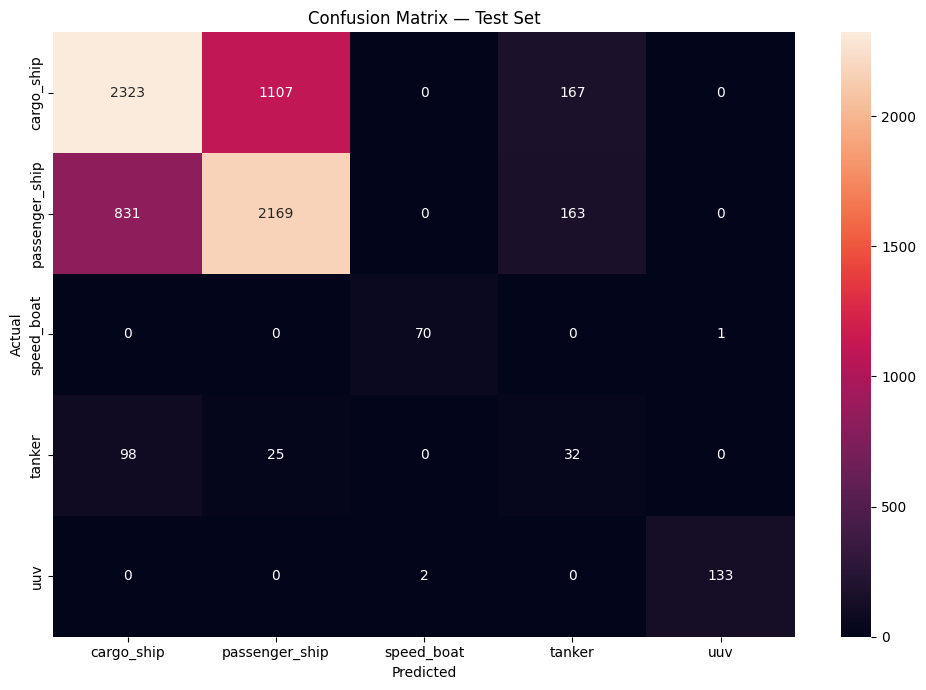

In [ ]:
# =========================
# EVALUATION ON TEST SET
# =========================
test_data   = np.load(os.path.join(SAVE_DIR, "test.npz"))
test_ds     = torch.utils.data.TensorDataset(
    torch.from_numpy(test_data["X"]).float(),
    torch.from_numpy(test_data["y"]).long()
)
test_loader = DataLoader(test_ds, batch_size=64)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

target_names = [idx_to_label[i] for i in label_list]
print("\n===== TEST SET RESULTS =====")
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

---
## STAGE 2 — Large Vessel Classifier (10s, 3-class)
Trains a separate CNN+GRU on cargo / passenger / tanker only.
Uses the SAME file-level train/val/test split from Stage 1 — no leakage.


In [ ]:
print(f"DURATION_S2      = {DURATION_S2}s")
print(f"N_FFT_S2         = {N_FFT_S2}")
print(f"HOP_LENGTH_S2    = {HOP_LENGTH_S2}")
print(f"N_MELS_S2        = {N_MELS_S2}")
print(f"FMIN_S2          = {FMIN_S2} Hz")
print(f"FMAX_S2          = {FMAX_S2} Hz")
print(f"TARGET_FRAMES_S2 = {TARGET_FRAMES_S2}")


DURATION_S2      = 10s
N_FFT_S2         = 4096
HOP_LENGTH_S2    = 512
N_MELS_S2        = 256
FMIN_S2          = 20 Hz
FMAX_S2          = 1000 Hz
TARGET_FRAMES_S2 = 314


In [ ]:
# =========================
# STAGE 2 — STEP 1: SEGMENT & EXTRACT FEATURES 
# =========================
TEMP_DIR_S2 = os.path.join(TEMP_DIR, "stage2")
os.makedirs(TEMP_DIR_S2, exist_ok=True)

# Load file-level split from Stage 1
train_files_s1 = np.load(os.path.join(TEMP_DIR, "train_files.npy"), allow_pickle=True)
val_files_s1   = np.load(os.path.join(TEMP_DIR, "val_files.npy"),   allow_pickle=True)
test_files_s1  = np.load(os.path.join(TEMP_DIR, "test_files.npy"),  allow_pickle=True)

# S2 classes — only large vessels
S2_CLASSES      = ["cargo_ship", "passenger_ship", "tanker"]
s2_label_to_idx = {c: i for i, c in enumerate(S2_CLASSES)}
s2_idx_to_label = {i: c for c, i in s2_label_to_idx.items()}
print("Stage 2 label mapping:", s2_label_to_idx)

# ── CHANGED: pull S2 files directly from Stage 1 split arrays
all_s1_files = np.concatenate([train_files_s1, val_files_s1, test_files_s1])
s2_wav_files = [Path(f) for f in all_s1_files
                if Path(f).parent.name in S2_CLASSES]
print(f"Found {len(s2_wav_files)} S2 wav files from Stage 1 split")

train_set = {str(f) for f in train_files_s1 if Path(f).parent.name in S2_CLASSES}
val_set   = {str(f) for f in val_files_s1   if Path(f).parent.name in S2_CLASSES}
test_set  = {str(f) for f in test_files_s1  if Path(f).parent.name in S2_CLASSES}

def get_split(fpath, train_set, val_set, test_set):
    f = str(fpath)
    if f in val_set:   return 'val'
    if f in test_set:  return 'test'
    if f in train_set: return 'train'
    return 'train'

# Verify
print(f"Split sizes — train: {len(train_set)} | val: {len(val_set)} | test: {len(test_set)}")

# Pass 1: count segments
print("\nPass 1: counting segments...")
seg_info = []
for fpath in tqdm(s2_wav_files):
    cls = fpath.parent.name
    sig = preprocess_audio(str(fpath))
    if sig is None:
        continue
    segs  = segment_audio_s2(sig)
    split = get_split(fpath, train_set, val_set, test_set)
    seg_info.append((str(fpath), cls, split, len(segs)))

n_train = sum(n for _, _, sp, n in seg_info if sp == 'train')
n_val   = sum(n for _, _, sp, n in seg_info if sp == 'val')
n_test  = sum(n for _, _, sp, n in seg_info if sp == 'test')
print(f"S2 segments — Train: {n_train} | Val: {n_val} | Test: {n_test}")
for cls in S2_CLASSES:
    ct = sum(n for _, c, sp, n in seg_info if c == cls and sp == 'train')
    print(f"  {cls}: {ct} train segments")

if n_val == 0 or n_test == 0:
    raise RuntimeError(
        f"Val/test split empty (n_val={n_val}, n_test={n_test}). "
        "Check that val_files_s1/test_files_s1 contain cargo/passenger/tanker files."
    )

# Pre-allocate memmaps
shape_train = (n_train, 3, N_MELS_S2, TARGET_FRAMES_S2)
shape_val   = (n_val,   3, N_MELS_S2, TARGET_FRAMES_S2)
shape_test  = (n_test,  3, N_MELS_S2, TARGET_FRAMES_S2)

X_s2_train = np.memmap(os.path.join(TEMP_DIR_S2, "X_train.dat"), dtype='float32', mode='w+', shape=shape_train)
X_s2_val   = np.memmap(os.path.join(TEMP_DIR_S2, "X_val.dat"),   dtype='float32', mode='w+', shape=shape_val)
X_s2_test  = np.memmap(os.path.join(TEMP_DIR_S2, "X_test.dat"),  dtype='float32', mode='w+', shape=shape_test)
y_s2_train = np.empty(n_train, dtype=np.int32)
y_s2_val   = np.empty(n_val,   dtype=np.int32)
y_s2_test  = np.empty(n_test,  dtype=np.int32)

# Pass 2: extract features
print("\nPass 2: extracting Stage 2 features...")
wi    = {'train': 0, 'val': 0, 'test': 0}
X_map = {'train': X_s2_train, 'val': X_s2_val, 'test': X_s2_test}
y_map = {'train': y_s2_train, 'val': y_s2_val, 'test': y_s2_test}

for fpath, cls, split, _ in tqdm(seg_info):
    sig = preprocess_audio(fpath)
    if sig is None:
        continue
    label_idx = s2_label_to_idx[cls]
    for seg in segment_audio_s2(sig):
        X_map[split][wi[split]] = extract_logmel_s2(seg, apply_specaug=False)
        y_map[split][wi[split]] = label_idx
        wi[split] += 1

for arr in [X_s2_train, X_s2_val, X_s2_test]:
    arr.flush()

print("\nStage 2 extraction complete.")
for sp in ['train', 'val', 'test']:
    counts = Counter(y_map[sp][:wi[sp]])
    print(f"  {sp}: {wi[sp]} segs — "
          f"{{{', '.join(f'{s2_idx_to_label[k]}:{v}' for k, v in sorted(counts.items()))}}}")

# Save labels and metadata
np.save(os.path.join(TEMP_DIR_S2, "y_train.npy"), y_s2_train[:wi['train']])
np.save(os.path.join(TEMP_DIR_S2, "y_val.npy"),   y_s2_val[:wi['val']])
np.save(os.path.join(TEMP_DIR_S2, "y_test.npy"),  y_s2_test[:wi['test']])
with open(os.path.join(TEMP_DIR_S2, "meta.json"), 'w') as f:
    json.dump({
        "label_to_idx": s2_label_to_idx,
        "n_train": wi['train'], "n_val": wi['val'], "n_test": wi['test'],
        "shape_train": list(shape_train),
        "shape_val":   list(shape_val),
        "shape_test":  list(shape_test),
    }, f)

import pickle
with open(os.path.join(TEMP_DIR_S2, "seg_info.pkl"), 'wb') as f:
    pickle.dump(seg_info, f)
print("seg_info saved to disk.")

Stage 2 label mapping: {'cargo_ship': 0, 'passenger_ship': 1, 'tanker': 2}
Found 319 S2 wav files from Stage 1 split
Split sizes — train: 223 | val: 48 | test: 48

Pass 1: counting segments...


100%|██████████| 319/319 [08:20<00:00,  1.57s/it]


S2 segments — Train: 11645 | Val: 2377 | Test: 2034
  cargo_ship: 5601 train segments
  passenger_ship: 5876 train segments
  tanker: 168 train segments

Pass 2: extracting Stage 2 features...


100%|██████████| 319/319 [13:04<00:00,  2.46s/it]



Stage 2 extraction complete.
  train: 11645 segs — {cargo_ship:5601, passenger_ship:5876, tanker:168}
  val: 2377 segs — {cargo_ship:883, passenger_ship:1426, tanker:68}
  test: 2034 segs — {cargo_ship:1064, passenger_ship:927, tanker:43}
seg_info saved to disk.


In [ ]:
import pickle 
if 'seg_info' not in dir():
    with open(os.path.join(TEMP_DIR_S2, "seg_info.pkl"), "rb") as f:
        seg_info = pickle.load(f)
    print("seg_info reloaded from disk.")
# =========================
# STAGE 2 — STEP 2: AUGMENT TRAINING SET (tanker 3x)
# Target: exactly 3x the real 10s tanker segment count.
# Val/test are NEVER augmented.
# =========================
s2_meta   = json.load(open(os.path.join(TEMP_DIR_S2, "meta.json")))
y_s2_tr   = np.load(os.path.join(TEMP_DIR_S2, "y_train.npy"))
n_s2_tr   = s2_meta["n_train"]

class_counts_s2 = Counter(y_s2_tr[:n_s2_tr])
print("S2 train class counts before aug:", {s2_idx_to_label[k]: v for k,v in class_counts_s2.items()})

tanker_idx    = s2_label_to_idx["tanker"]
tanker_count  = class_counts_s2[tanker_idx]

# Augment tanker to exactly 3x its real 10s segment count
# Remaining imbalance vs cargo/passenger handled by WeightedRandomSampler + FocalLoss
target_tanker = tanker_count * 3
n_aug_needed  = target_tanker - tanker_count   # = 2x tanker_count
print(f"Tanker real segments:  {tanker_count}")
print(f"Tanker target (3x):    {target_tanker}  (+{n_aug_needed} augmented)")

# Load tanker source audio files (train split only)
tanker_files = [fpath for fpath, cls, sp, _ in seg_info
                if cls == 'tanker' and sp == 'train']
print(f"Tanker source files available: {len(tanker_files)}")

n_s2_tr_aug  = n_s2_tr + n_aug_needed
shape_tr_aug = (n_s2_tr_aug, 3, N_MELS_S2, TARGET_FRAMES_S2)

X_s2_train_aug = np.memmap(os.path.join(TEMP_DIR_S2, "X_train_aug.dat"),
                            dtype='float32', mode='w+', shape=shape_tr_aug)

src_mmap   = np.memmap(os.path.join(TEMP_DIR_S2, "X_train.dat"),
                        dtype='float32', mode='r', shape=tuple(s2_meta["shape_train"]))
COPY_CHUNK = 200
for _i in range(0, n_s2_tr, COPY_CHUNK):
    chunk = src_mmap[_i:_i+COPY_CHUNK]
    X_s2_train_aug[_i:_i+len(chunk)] = chunk
del src_mmap
gc.collect()
y_s2_train_aug = np.empty(n_s2_tr_aug, dtype=np.int32)
y_s2_train_aug[:n_s2_tr] = y_s2_tr

# Generate augmented tanker samples
write_idx      = n_s2_tr
generated      = 0
audio_cache_s2 = {}

while generated < n_aug_needed:
    fpath = np.random.choice(tanker_files)
    if fpath not in audio_cache_s2:
        sig = preprocess_audio(fpath)
        if sig is None:
            continue
        audio_cache_s2[fpath] = sig
    for seg in segment_audio_s2(audio_cache_s2[fpath]):
        if generated >= n_aug_needed:
            break
        spec = extract_logmel_s2(augment_one(seg, stage2=True), apply_specaug=True)
        X_s2_train_aug[write_idx] = spec
        y_s2_train_aug[write_idx] = tanker_idx
        write_idx += 1
        generated += 1

X_s2_train_aug.flush()
np.save(os.path.join(TEMP_DIR_S2, "y_train_aug.npy"), y_s2_train_aug)

counts_after = Counter(y_s2_train_aug.tolist())
print("S2 train counts after aug:",
      {s2_idx_to_label[k]: v for k,v in sorted(counts_after.items())})
print(f"Total S2 train segments: {n_s2_tr_aug}")


s2_meta["n_train_aug"]    = n_s2_tr_aug
s2_meta["shape_tr_aug"]   = list(shape_tr_aug)
s2_meta["tanker_real"]    = tanker_count
s2_meta["tanker_target"]  = target_tanker
with open(os.path.join(TEMP_DIR_S2, "meta.json"), 'w') as f:
    json.dump(s2_meta, f, indent=2)
print("meta.json updated with n_train_aug.")


S2 train class counts before aug: {'tanker': 168, 'passenger_ship': 5876, 'cargo_ship': 5601}
Tanker real segments:  168
Tanker target (3x):    504  (+336 augmented)
Tanker source files available: 18
S2 train counts after aug: {'cargo_ship': 5601, 'passenger_ship': 5876, 'tanker': 504}
Total S2 train segments: 11981
meta.json updated with n_train_aug.


In [ ]:
# =========================
# STAGE 2 — STEP 3: NORMALIZE
# =========================
CHUNK = 500
device_s2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

s2_meta     = json.load(open(os.path.join(TEMP_DIR_S2, "meta.json")))
n_s2_tr_aug = s2_meta["n_train_aug"]
shape_tr_aug = tuple(s2_meta["shape_tr_aug"])

X_aug_mmap = np.memmap(os.path.join(TEMP_DIR_S2, "X_train_aug.dat"),
                        dtype='float32', mode='r', shape=shape_tr_aug)

# Pass 1: compute mean and std
sum_v, sum_sq_v, n_pix = 0.0, 0.0, 0
for i in tqdm(range(0, n_s2_tr_aug, CHUNK), desc="S2 stats"):
    c = torch.from_numpy(X_aug_mmap[i:i+CHUNK].astype(np.float32)).to(device_s2)
    sum_v    += c.sum().item()
    sum_sq_v += c.pow(2).sum().item()
    n_pix    += c.numel()
    del c

s2_mean = sum_v / n_pix
s2_std  = float(np.sqrt(sum_sq_v / n_pix - s2_mean**2)) + 1e-8
print(f"S2 mean: {s2_mean:.4f}  std: {s2_std:.4f}")

# Save stats into meta for restore cell
s2_meta["s2_mean"] = s2_mean
s2_meta["s2_std"]  = s2_std
with open(os.path.join(TEMP_DIR_S2, "meta.json"), 'w') as f:
    json.dump(s2_meta, f, indent=2)

# Pass 2: write normalised train memmap
X_s2_norm_path = os.path.join(TEMP_DIR_S2, "X_train_norm.dat")
X_s2_norm = np.memmap(X_s2_norm_path, dtype='float32', mode='w+', shape=shape_tr_aug)
for i in tqdm(range(0, n_s2_tr_aug, CHUNK), desc="S2 normalize"):
    c = torch.from_numpy(X_aug_mmap[i:i+CHUNK].astype(np.float32)).to(device_s2)
    X_s2_norm[i:i+CHUNK] = ((c - s2_mean) / s2_std).cpu().numpy()
    del c
X_s2_norm.flush()
del X_s2_norm
gc.collect()


X_s2_val_raw  = np.memmap(os.path.join(TEMP_DIR_S2, "X_val.dat"),
                            dtype='float32', mode='r', shape=tuple(s2_meta["shape_val"]))
X_s2_test_raw = np.memmap(os.path.join(TEMP_DIR_S2, "X_test.dat"),
                            dtype='float32', mode='r', shape=tuple(s2_meta["shape_test"]))
y_s2_val_arr  = np.load(os.path.join(TEMP_DIR_S2, "y_val.npy"))
y_s2_test_arr = np.load(os.path.join(TEMP_DIR_S2, "y_test.npy"))

X_s2_val_norm  = (np.array(X_s2_val_raw,  dtype=np.float32) - s2_mean) / s2_std
X_s2_test_norm = (np.array(X_s2_test_raw, dtype=np.float32) - s2_mean) / s2_std

np.savez(os.path.join(TEMP_DIR_S2, "val_norm.npz"),  X=X_s2_val_norm,  y=y_s2_val_arr)
np.savez(os.path.join(TEMP_DIR_S2, "test_norm.npz"), X=X_s2_test_norm, y=y_s2_test_arr)
del X_s2_val_norm, X_s2_test_norm
gc.collect()

# Push all S2 files to Drive
for fname in ["X_train_norm.dat", "y_train_aug.npy",
              "val_norm.npz", "test_norm.npz", "meta.json"]:
    src = os.path.join(TEMP_DIR_S2, fname)
    dst = os.path.join(SAVE_DIR, "stage2_" + fname)
    if os.path.exists(src):
        if os.path.exists(dst): os.remove(dst)
        shutil.copy(src, dst)
        print(f"  Saved to Drive: stage2_{fname}")

print("Stage 2 preprocessing complete.")


---
## STAGE 2 — RESTORE
Run this cell **instead of** S2 Steps 1–3 on subsequent sessions.
Copies processed files from Drive back to local SSD and reloads all metadata.


In [ ]:
# =========================
# STAGE 2 — RESTORE (skip Steps 1-3 on subsequent sessions)
# =========================
TEMP_DIR_S2 = os.path.join(TEMP_DIR, "stage2")
os.makedirs(TEMP_DIR_S2, exist_ok=True)

S2_DRIVE_FILES = [
    "stage2_meta.json",
    "stage2_y_train_aug.npy",
    "stage2_val_norm.npz",
    "stage2_test_norm.npz",
]

for fname in S2_DRIVE_FILES:
    src = os.path.join(SAVE_DIR, fname)
    dst = os.path.join(TEMP_DIR_S2, fname.replace("stage2_", ""))
    if not os.path.exists(dst):
        print(f"Restoring {fname}...")
        shutil.copy(src, dst)
    else:
        print(f"Already local: {fname.replace('stage2_', '')}")

s2_local_path = "/content/s2_X_train_norm.dat"
s2_drive_path = os.path.join(SAVE_DIR, "stage2_X_train_norm.dat")
if not os.path.exists(s2_local_path):
    print("Copying stage2_X_train_norm.dat to local SSD (this may take a minute)...")
    shutil.copy(s2_drive_path, s2_local_path)
    print("Done.")
else:
    drive_size = os.path.getsize(s2_drive_path)
    local_size = os.path.getsize(s2_local_path)
    if local_size != drive_size:
        print("Size mismatch — re-copying...")
        shutil.copy(s2_drive_path, s2_local_path)
    print(f"Local S2 memmap valid ({local_size/1e9:.2f} GB).")

s2_meta         = json.load(open(os.path.join(TEMP_DIR_S2, "meta.json")))
s2_label_to_idx = s2_meta["label_to_idx"]
s2_idx_to_label = {int(v): k for k, v in s2_label_to_idx.items()}
s2_label_list   = sorted(s2_idx_to_label.keys())
n_s2_classes    = len(s2_label_list)
n_s2_tr_aug     = s2_meta["n_train_aug"]
shape_tr_aug    = tuple(s2_meta["shape_tr_aug"])
s2_mean         = s2_meta["s2_mean"]
s2_std          = s2_meta["s2_std"]

y_s2_train_aug  = np.load(os.path.join(TEMP_DIR_S2, "y_train_aug.npy"))

print(f"\nStage 2 restored.")
print(f"  label_to_idx:  {s2_label_to_idx}")
print(f"  n_train_aug:   {n_s2_tr_aug}")
print(f"  s2_mean/std:   {s2_mean:.4f} / {s2_std:.4f}")
print(f"  tanker real:   {s2_meta.get('tanker_real', 'n/a')}  target: {s2_meta.get('tanker_target', 'n/a')}")
counts = Counter(y_s2_train_aug.tolist())
print(f"  Train counts:  {{{', '.join(f'{s2_idx_to_label[k]}:{v}' for k,v in sorted(counts.items()))}}}")


Restoring stage2_meta.json...
Restoring stage2_y_train_aug.npy...
Restoring stage2_val_norm.npz...
Restoring stage2_test_norm.npz...
Copying stage2_X_train_norm.dat to local SSD (this may take a minute)...
Done.

Stage 2 restored.
  label_to_idx:  {'cargo_ship': 0, 'passenger_ship': 1, 'tanker': 2}
  n_train_aug:   11981
  s2_mean/std:   -7.2209 / 11.7172
  tanker real:   168  target: 504
  Train counts:  {cargo_ship:5601, passenger_ship:5876, tanker:504}


---
## STAGE 2 — Training (CNN+GRU, 3-class)


In [ ]:
# =========================
# STAGE 2 — BUILD LOADERS
# =========================
s2_meta      = json.load(open(os.path.join(TEMP_DIR_S2, "meta.json")))
s2_label_to_idx = s2_meta["label_to_idx"]
s2_idx_to_label = {int(v): k for k,v in s2_label_to_idx.items()}
s2_label_list   = sorted(s2_idx_to_label.keys())
n_s2_classes    = len(s2_label_list)

y_s2_train_aug = np.load(os.path.join(TEMP_DIR_S2, "y_train_aug.npy"))
n_s2_tr_aug    = len(y_s2_train_aug)

# Stage to local SSD
s2_local_path = "/content/s2_X_train_norm.dat"
s2_src_path   = os.path.join(SAVE_DIR, "stage2_X_train_norm.dat")
if not os.path.exists(s2_local_path):
    print("Staging S2 train memmap to local SSD...")
    shutil.copy(s2_src_path, s2_local_path)

s2_train_ds = ShipDataset(
    s2_local_path, y_s2_train_aug,
    shape=(n_s2_tr_aug, 3, N_MELS_S2, TARGET_FRAMES_S2)
)

# WeightedRandomSampler for tanker
s2_sample_counts  = np.bincount(y_s2_train_aug, minlength=n_s2_classes).astype(np.float32)
s2_sample_weights = np.array([1.0/s2_sample_counts[y] for y in y_s2_train_aug], dtype=np.float32)
s2_sampler        = WeightedRandomSampler(torch.from_numpy(s2_sample_weights),
                                           len(s2_sample_weights), replacement=True)

s2_train_loader = DataLoader(s2_train_ds, batch_size=32, sampler=s2_sampler,
                              num_workers=2, pin_memory=True)

_s2_val  = np.load(os.path.join(TEMP_DIR_S2, "val_norm.npz"))
_s2_test = np.load(os.path.join(TEMP_DIR_S2, "test_norm.npz"))
s2_val_loader  = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(_s2_val["X"]).float(),
                                   torch.from_numpy(_s2_val["y"]).long()),
    batch_size=32, num_workers=2, pin_memory=True)
s2_test_loader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(_s2_test["X"]).float(),
                                   torch.from_numpy(_s2_test["y"]).long()),
    batch_size=32, num_workers=2, pin_memory=True)

print(f"S2 train: {len(s2_train_ds)} | val: {len(_s2_val['y'])} | test: {len(_s2_test['y'])}")
x_b, y_b = next(iter(s2_train_loader))
print(f"Batch shape: {x_b.shape}  labels unique: {y_b.unique().tolist()}")


S2 train: 11981 | val: 2377 | test: 2034
Batch shape: torch.Size([32, 3, 256, 314])  labels unique: [0, 1, 2]


In [ ]:
# =========================
# STAGE 2 — TRAINING SETUP
# =========================
device_s2  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
s2_model   = LargeVesselCNNGRU(num_classes=3, n_mels=N_MELS_S2).to(device_s2)

s2_class_counts_arr = np.bincount(y_s2_train_aug, minlength=3).astype(np.float32)
s2_raw_w = 1.0 / (s2_class_counts_arr + 1e-6)
s2_raw_w = s2_raw_w / s2_raw_w.sum() * 3
s2_class_weights = torch.FloatTensor(s2_raw_w).to(device_s2)
print("S2 class weights:", {s2_idx_to_label[i]: f"{w:.3f}" for i,w in enumerate(s2_raw_w)})

s2_criterion = FocalLoss(gamma=2.0, weight=s2_class_weights)
s2_optimizer = torch.optim.Adam(s2_model.parameters(), lr=5e-5, weight_decay=1e-4)
s2_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    s2_optimizer, mode='max', patience=4, factor=0.5)

total_params = sum(p.numel() for p in s2_model.parameters() if p.requires_grad)
print(f"S2 model params: {total_params:,}")


S2 class weights: {'cargo_ship': '0.230', 'passenger_ship': '0.219', 'tanker': '2.552'}
S2 model params: 2,072,851


In [ ]:
# =========================
# STAGE 2 — TRAINING LOOP
# =========================
S2_EPOCHS   = 40
S2_MODEL_PATH = os.path.join(SAVE_DIR, "best_s2_model.pth")
best_s2_f1  = 0.0
patience_ctr= 0
S2_EARLY_STOP = 12

for epoch in range(S2_EPOCHS):
    s2_model.train()
    train_loss = 0.0
    pbar = tqdm(s2_train_loader, desc=f"S2 Epoch {epoch+1}/{S2_EPOCHS}")
    for specs, labels in pbar:
        specs  = specs.to(device_s2, non_blocking=True)
        labels = labels.to(device_s2, non_blocking=True)
        s2_optimizer.zero_grad()
        loss = s2_criterion(s2_model(specs), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(s2_model.parameters(), 1.0)
        s2_optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    s2_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for specs, labels in s2_val_loader:
            preds = s2_model(specs.to(device_s2)).argmax(1).cpu().numpy()
            all_preds.extend(preds); all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    val_f1  = f1_score(all_labels, all_preds, average='macro')
    val_acc = np.mean(all_preds == all_labels)
    s2_scheduler.step(val_f1)

    per_class_recall = {s2_idx_to_label[i]: f"{np.mean(all_preds[all_labels==i]==i):.2f}"
                        for i in s2_label_list if (all_labels==i).sum()>0}
    print(f"S2 Epoch {epoch+1:03d} | Loss: {train_loss/len(s2_train_loader):.4f} "
          f"| Val Acc: {val_acc:.4f} | Val Macro F1: {val_f1:.4f}")
    print(f"  Per-class recall: {per_class_recall}")
    print(f"  Pred dist: {np.bincount(all_preds, minlength=3)}")

    if val_f1 > best_s2_f1:
        best_s2_f1   = val_f1
        patience_ctr = 0
        torch.save(s2_model.state_dict(), S2_MODEL_PATH)
        print(f"  ✓ Best S2 model saved (F1={best_s2_f1:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= S2_EARLY_STOP:
            print(f"Early stopping at S2 epoch {epoch+1}")
            break


S2 Epoch 1/40: 100%|██████████| 375/375 [02:29<00:00,  2.50it/s, loss=0.0951]


S2 Epoch 001 | Loss: 0.0900 | Val Acc: 0.0682 | Val Macro F1: 0.0694
  Per-class recall: {'cargo_ship': '0.04', 'passenger_ship': '0.04', 'tanker': '0.99'}
  Pred dist: [  84  125 2168]
  ✓ Best S2 model saved (F1=0.0694)


S2 Epoch 2/40: 100%|██████████| 375/375 [02:40<00:00,  2.33it/s, loss=0.0329]


S2 Epoch 002 | Loss: 0.0442 | Val Acc: 0.3732 | Val Macro F1: 0.2723
  Per-class recall: {'cargo_ship': '0.06', 'passenger_ship': '0.54', 'tanker': '0.96'}
  Pred dist: [ 121 1124 1132]
  ✓ Best S2 model saved (F1=0.2723)


S2 Epoch 3/40: 100%|██████████| 375/375 [02:40<00:00,  2.33it/s, loss=0.0158]


...

S2 Epoch 038 | Loss: 0.0019 | Val Acc: 0.7143 | Val Macro F1: 0.4892
  Per-class recall: {'cargo_ship': '0.64', 'passenger_ship': '0.80', 'tanker': '0.03'}
  Pred dist: [ 888 1481    8]


S2 Epoch 39/40: 100%|██████████| 375/375 [02:41<00:00,  2.32it/s, loss=0.0031]


S2 Epoch 039 | Loss: 0.0018 | Val Acc: 0.6971 | Val Macro F1: 0.5043
  Per-class recall: {'cargo_ship': '0.70', 'passenger_ship': '0.73', 'tanker': '0.07'}
  Pred dist: [1049 1311   17]


S2 Epoch 40/40: 100%|██████████| 375/375 [02:41<00:00,  2.32it/s, loss=0.0011]


S2 Epoch 040 | Loss: 0.0020 | Val Acc: 0.7017 | Val Macro F1: 0.5009
  Per-class recall: {'cargo_ship': '0.68', 'passenger_ship': '0.75', 'tanker': '0.06'}
  Pred dist: [1001 1367    9]


---
## EVALUATION — Hierarchical Inference on Test Set
Stage 1 predicts all 5 classes. When Stage 1 predicts `large_vessel` bucket
(cargo/passenger/tanker), Stage 2 refines the prediction.
Standalone Stage 2 evaluation is also shown for diagnostic purposes.



===== STAGE 2 TEST RESULTS (large vessel only) =====
                precision    recall  f1-score   support

    cargo_ship       0.81      0.74      0.77      1064
passenger_ship       0.72      0.77      0.74       927
        tanker       0.10      0.19      0.13        43

      accuracy                           0.74      2034
     macro avg       0.54      0.56      0.55      2034
  weighted avg       0.75      0.74      0.75      2034



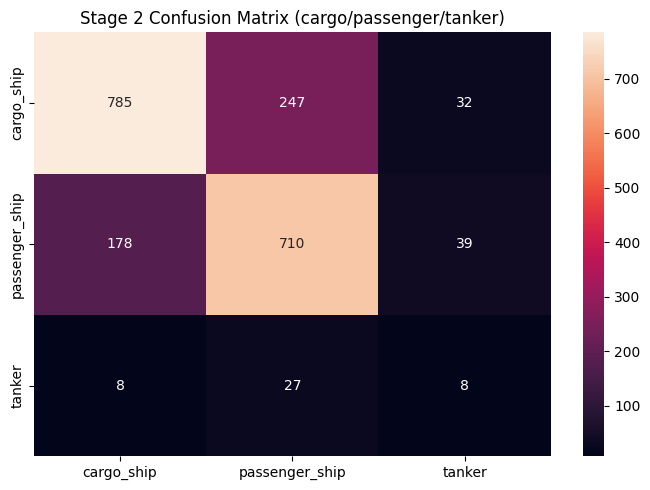

In [ ]:
# =========================
# STAGE 2 — TEST SET EVALUATION  
# =========================
s2_model.load_state_dict(torch.load(S2_MODEL_PATH, map_location=device_s2))
s2_model.eval()

s2_preds, s2_true = [], []
with torch.no_grad():
    for specs, labels in s2_test_loader:
        preds = s2_model(specs.to(device_s2)).argmax(1).cpu().numpy()
        s2_preds.extend(preds); s2_true.extend(labels.numpy())

s2_names = [s2_idx_to_label[i] for i in s2_label_list]
print("\n===== STAGE 2 TEST RESULTS (large vessel only) =====")
print(classification_report(s2_true, s2_preds, target_names=s2_names))

cm2 = confusion_matrix(s2_true, s2_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=s2_names, yticklabels=s2_names)
plt.title("Stage 2 Confusion Matrix (cargo/passenger/tanker)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "cm_stage2.png"), dpi=150)
plt.show()


In [ ]:
# =========================
# STAGE 2 — t-SNE SETUP  
# =========================
import os, json, numpy as np, torch

SAVE_DIR      = r"/content/drive/MyDrive/ID5030 - results"
TEMP_DIR_S2   = r"/content/temp_preprocessed/stage2"
N_MELS_S2     = 256
S2_MODEL_PATH = os.path.join(SAVE_DIR, "best_s2_model.pth")
device_s2     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

s2_meta         = json.load(open(os.path.join(TEMP_DIR_S2, "meta.json")))
s2_label_to_idx = s2_meta["label_to_idx"]
s2_idx_to_label = {int(v): k for k, v in s2_label_to_idx.items()}
s2_label_list   = sorted(s2_idx_to_label.keys())

_s2_val = np.load(os.path.join(TEMP_DIR_S2, "val_norm.npz"))
s2_val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.from_numpy(_s2_val["X"]).float(),
        torch.from_numpy(_s2_val["y"]).long()
    ),
    batch_size=32, num_workers=2, pin_memory=True
)

s2_model = LargeVesselCNNGRU(num_classes=3, n_mels=N_MELS_S2).to(device_s2)
print("Ready.")

Ready.


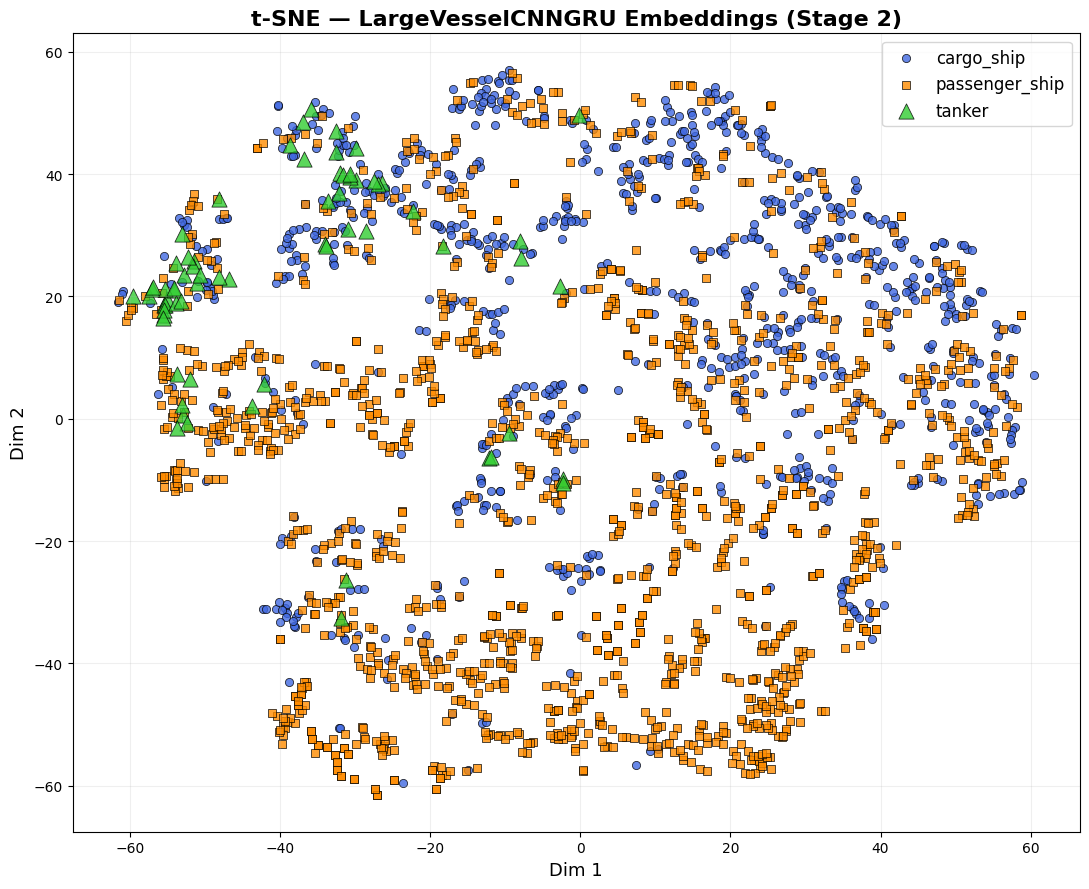

In [ ]:
# =========================
# CLASS-WISE VISUAL SETTINGS
# =========================
class_colors = {
    0: 'royalblue',   # cargo_ship
    1: 'darkorange',  # passenger_ship
    2: 'limegreen'    # tanker
}

class_sizes = {
    0: 35,   # cargo_ship
    1: 35,   # passenger_ship
    2: 120   # tanker (make larger for visibility)
}

class_markers = {
    0: 'o',   # circle
    1: 's',   # square
    2: '^'    # triangle
}

# =========================
# PLOT
# =========================
plt.figure(figsize=(11, 9))

for cls_id in s2_label_list:

    idx = y == cls_id

    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],

        label=s2_idx_to_label[cls_id],

        c=class_colors[cls_id],
        s=class_sizes[cls_id],
        marker=class_markers[cls_id],

        alpha=0.8,

        edgecolors='black',
        linewidths=0.6
    )

plt.title(
    "t-SNE — LargeVesselCNNGRU Embeddings (Stage 2)",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Dim 1", fontsize=13)
plt.ylabel("Dim 2", fontsize=13)

plt.legend(fontsize=12)

plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR, "tsne_stage2_contrast.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()